<a href="https://colab.research.google.com/github/ENSiGN-CODES/AI-ML-project/blob/main/PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
s# Step 1: Create a new directory for extraction
!mkdir extracted_data

# Step 2: Extract the ZIP file into the extracted_data folder
!unzip 1512427.zip -d extracted_data

print("Extraction complete!")

Archive:  1512427.zip
 extracting: extracted_data/brainTumorDataPublic_1-766.zip  
 extracting: extracted_data/brainTumorDataPublic_1533-2298.zip  
 extracting: extracted_data/brainTumorDataPublic_767-1532.zip  
 extracting: extracted_data/brainTumorDataPublic_2299-3064.zip  
 extracting: extracted_data/cvind.mat  
 extracting: extracted_data/README 2024.txt  
Extraction complete!


In [ ]:
# Step 1: Create a new directory for final extraction
!mkdir final_extracted_data

# Step 2: Extract each ZIP file into the final_extracted_data folder
!unzip extracted_data/brainTumorDataPublic_1-766.zip -d final_extracted_data
!unzip extracted_data/brainTumorDataPublic_767-1532.zip -d final_extracted_data
!unzip extracted_data/brainTumorDataPublic_1533-2298.zip -d final_extracted_data
!unzip extracted_data/brainTumorDataPublic_2299-3064.zip -d final_extracted_data

print("Final extraction complete!")

Archive:  extracted_data/brainTumorDataPublic_1-766.zip
  inflating: final_extracted_data/1.mat  
  inflating: final_extracted_data/10.mat  
  inflating: final_extracted_data/100.mat  
  inflating: final_extracted_data/101.mat  
  inflating: final_extracted_data/102.mat  
  inflating: final_extracted_data/103.mat  
  inflating: final_extracted_data/104.mat  
  inflating: final_extracted_data/105.mat  
  inflating: final_extracted_data/106.mat  
  inflating: final_extracted_data/107.mat  
  inflating: final_extracted_data/108.mat  
  inflating: final_extracted_data/109.mat  
  inflating: final_extracted_data/11.mat  
  inflating: final_extracted_data/110.mat  
  inflating: final_extracted_data/111.mat  
  inflating: final_extracted_data/112.mat  
  inflating: final_extracted_data/113.mat  
  inflating: final_extracted_data/114.mat  
  inflating: final_extracted_data/115.mat  
  inflating: final_extracted_data/116.mat  
  inflating: final_extracted_data/117.mat  
  inflating: final_extra

In [ ]:
!ls final_extracted_data

1000.mat  1346.mat  1691.mat  2035.mat	2380.mat  2725.mat  310.mat  656.mat
1001.mat  1347.mat  1692.mat  2036.mat	2381.mat  2726.mat  311.mat  657.mat
1002.mat  1348.mat  1693.mat  2037.mat	2382.mat  2727.mat  312.mat  658.mat
1003.mat  1349.mat  1694.mat  2038.mat	2383.mat  2728.mat  313.mat  659.mat
1004.mat  134.mat   1695.mat  2039.mat	2384.mat  2729.mat  314.mat  65.mat
1005.mat  1350.mat  1696.mat  203.mat	2385.mat  272.mat   315.mat  660.mat
1006.mat  1351.mat  1697.mat  2040.mat	2386.mat  2730.mat  316.mat  661.mat
1007.mat  1352.mat  1698.mat  2041.mat	2387.mat  2731.mat  317.mat  662.mat
1008.mat  1353.mat  1699.mat  2042.mat	2388.mat  2732.mat  318.mat  663.mat
1009.mat  1354.mat  169.mat   2043.mat	2389.mat  2733.mat  319.mat  664.mat
100.mat   1355.mat  16.mat    2044.mat	238.mat   2734.mat  31.mat   665.mat
1010.mat  1356.mat  1700.mat  2045.mat	2390.mat  2735.mat  320.mat  666.mat
1011.mat  1357.mat  1701.mat  2046.mat	2391.mat  2736.mat  321.mat  667.mat
1012.mat  1358

In [ ]:
import cv2

class MRI(Dataset):
    def __init__(self):
        images = []
        labels = []

        # Load all .mat files
        mat_files = glob.glob("final_extracted_data/*.mat")
        print(f"Number of .mat files found: {len(mat_files)}")

        for f in mat_files:
            try:
                # Load the .mat file using h5py
                with h5py.File(f, 'r') as data:
                    # Access the 'cjdata' group
                    cjdata = data['cjdata']

                    # Extract image and label
                    img = np.array(cjdata['image'])  # Image data
                    label = np.array(cjdata['label'])  # Label data

                    # Resize image to (512, 512)
                    img = cv2.resize(img, (512, 512))

                    # Check label shape
                    if label.shape != (1, 1):
                        print(f"Skipping file {f}: Unexpected label shape {label.shape}")
                        continue

                    # Normalize the image to [0, 1]
                    img = img.astype(np.float32) / np.max(img)

                    # Add channel dimension (1, H, W) for grayscale images
                    img = np.expand_dims(img, axis=0)  # Shape: (1, 512, 512)

                    # Append to lists
                    images.append(img)
                    labels.append(label[0][0])  # Extract scalar label (e.g., 1.0 or 0.0)

            except Exception as e:
                print(f"Failed to load file {f}: {e}")

        # Convert to numpy arrays
        self.images = np.array(images, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        sample = {'image': self.images[index], 'label': self.labels[index]}
        return sample

NameError: name 'Dataset' is not defined

Number of .mat files found: 3064
Dataset size: 3064
Displaying random images from the dataset...


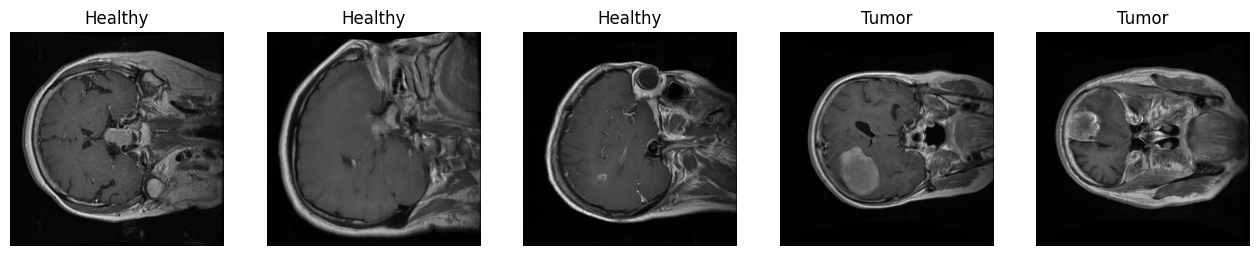

Unique values in y_true: [1. 2. 3.]
Unique values in outputs: [0.46864778 0.47044203 0.47059467 ... 0.48219192 0.48238236 0.48247474]
Accuracy: 0.0


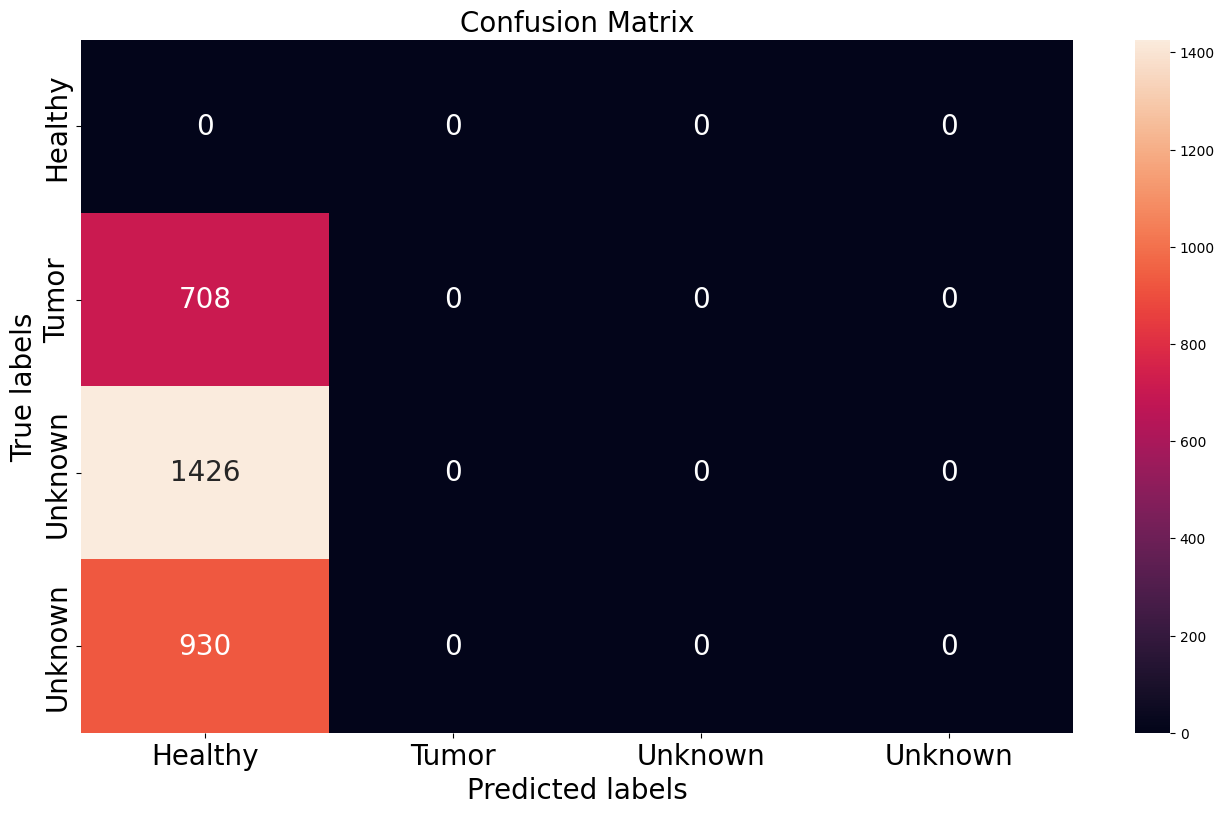

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import h5py
import torch.nn as nn
import torch.nn.functional as F
import seaborn as sns
import cv2

# Dataset Class
class MRI(Dataset):
    def __init__(self):
        images = []
        labels = []

        # Load all .mat files
        mat_files = glob.glob("final_extracted_data/*.mat")
        print(f"Number of .mat files found: {len(mat_files)}")

        for f in mat_files:
            try:
                # Load the .mat file using h5py
                with h5py.File(f, 'r') as data:
                    # Access the 'cjdata' group
                    cjdata = data['cjdata']

                    # Extract image and label
                    img = np.array(cjdata['image'])  # Image data
                    label = np.array(cjdata['label'])  # Label data

                    # Resize image to (512, 512)
                    img = cv2.resize(img, (512, 512))

                    # Check label shape
                    if label.shape != (1, 1):
                        print(f"Skipping file {f}: Unexpected label shape {label.shape}")
                        continue

                    # Normalize the image to [0, 1]
                    img = img.astype(np.float32) / np.max(img)

                    # Add channel dimension (1, H, W) for grayscale images
                    img = np.expand_dims(img, axis=0)  # Shape: (1, 512, 512)

                    # Append to lists
                    images.append(img)
                    labels.append(label[0][0])  # Extract scalar label (e.g., 1.0 or 0.0)

            except Exception as e:
                print(f"Failed to load file {f}: {e}")

        # Convert to numpy arrays
        self.images = np.array(images, dtype=np.float32)
        self.labels = np.array(labels, dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        sample = {'image': self.images[index], 'label': self.labels[index]}
        return sample


# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.cnn_model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5),  # Input channel = 1
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=5),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=5)
        )
        self.fc_model = nn.Sequential(
            nn.Linear(in_features=6400, out_features=120),  # Updated input size
            nn.Tanh(),
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=1)
        )

    def forward(self, x):
        x = self.cnn_model(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_model(x)
        x = F.sigmoid(x)
        return x


# Threshold Function
def threshold(scores, threshold=0.50):
    return (scores >= threshold).astype(np.float32)


# Function to Display Random Images
def plot_random_images(dataset, num=5):
    if len(dataset) == 0:
        print("Dataset is empty. Cannot display images.")
        return

    indices = np.random.choice(len(dataset), num, replace=False)
    plt.figure(figsize=(16, 9))
    for i, idx in enumerate(indices):
        sample = dataset[idx]
        img = sample['image']
        label = sample['label']

        # Reshape image to (H, W) for grayscale images
        img = img.squeeze(0)  # Remove channel dimension (1, H, W) -> (H, W)

        plt.subplot(1, num, i + 1)
        plt.title("Tumor" if label == 1 else "Healthy")
        plt.imshow(img, cmap='gray')  # Use grayscale colormap
        plt.axis('off')
    plt.show()


# Main Execution
if __name__ == "__main__":
    # Dataset
    mri_dataset = MRI()

    # Check dataset size
    print(f"Dataset size: {len(mri_dataset)}")
    if len(mri_dataset) == 0:
        raise ValueError("Dataset is empty. Please check the .mat file paths and keys.")

    # Display Random Images
    print("Displaying random images from the dataset...")
    plot_random_images(mri_dataset, num=5)

    # Device Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Model Initialization
    model = CNN().to(device)

    # DataLoader
    dataloader = DataLoader(mri_dataset, batch_size=32, shuffle=False)

    # Evaluation
    model.eval()
    outputs = []
    y_true = []

    with torch.no_grad():
        for D in dataloader:
            image = D['image'].to(device)
            label = D['label'].to(device)

            y_hat = model(image)

            outputs.append(y_hat.cpu().detach().numpy())
            y_true.append(label.cpu().detach().numpy())

    outputs = np.concatenate(outputs, axis=0).squeeze()
    y_true = np.concatenate(y_true, axis=0).squeeze()

    # Debugging: Check unique values in y_true and outputs
    print("Unique values in y_true:", np.unique(y_true))
    print("Unique values in outputs:", np.unique(outputs))

    # Threshold predictions
    y_pred = threshold(outputs)

    # Accuracy Calculation
    print("Accuracy:", accuracy_score(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    # Get unique labels from y_true and predictions
    unique_labels = np.unique(np.concatenate((y_true, y_pred)))

    # Map labels to meaningful names
    label_names = ['Healthy', 'Tumor']
    if len(unique_labels) > 2:
        label_names += ['Unknown'] * (len(unique_labels) - 2)

    # Plot confusion matrix
    plt.figure(figsize=(16, 9))
    ax = plt.subplot()
    sns.heatmap(cm, annot=True, fmt='g', ax=ax, annot_kws={"size": 20})

    # Labels, Title, and Ticks
    ax.set_xlabel('Predicted labels', fontsize=20)
    ax.set_ylabel('True labels', fontsize=20)
    ax.set_title('Confusion Matrix', fontsize=20)
    ax.xaxis.set_ticklabels(label_names, fontsize=20)
    ax.yaxis.set_ticklabels(label_names, fontsize=20)

    plt.show()

Number of .mat files found: 3064
Dataset size: 3064
Epoch 1, Loss: 0.6154
Epoch 2, Loss: 0.3928
Epoch 3, Loss: 0.3121
Epoch 4, Loss: 0.2322
Epoch 5, Loss: 0.1675
Epoch 6, Loss: 0.1281
Epoch 7, Loss: 0.0740
Epoch 8, Loss: 0.0492
Epoch 9, Loss: 0.0293
Epoch 10, Loss: 0.0118
Performance Metrics:
Accuracy: 0.9990
Precision: 0.9990
Recall: 0.9990
F1-Score: 0.9990


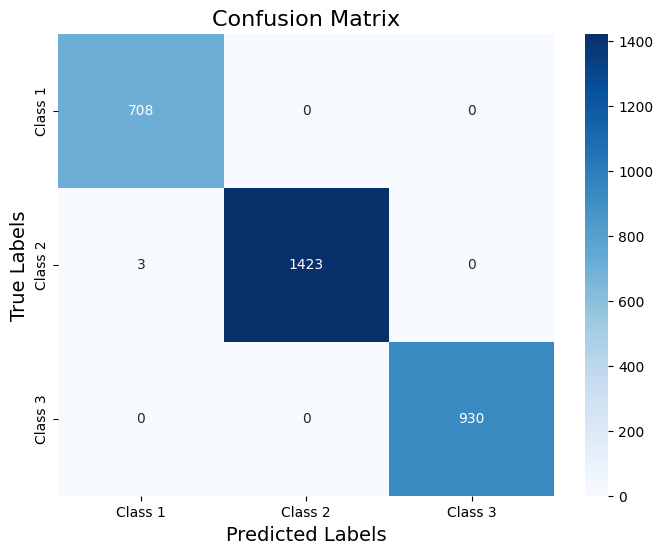

In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import h5py
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import cv2

# Dataset Class
class MRI(Dataset):
    def __init__(self):
        self.mat_files = glob.glob("final_extracted_data/*.mat")
        print(f"Number of .mat files found: {len(self.mat_files)}")

    def __len__(self):
        return len(self.mat_files)

    def __getitem__(self, index):
        try:
            # Load the .mat file using h5py
            f = self.mat_files[index]
            with h5py.File(f, 'r') as data:
                cjdata = data['cjdata']

                # Extract image and label
                img = np.array(cjdata['image'])  # Image data
                label = np.array(cjdata['label'])  # Label data

                # Resize image to (512, 512)
                img = cv2.resize(img, (512, 512))

                # Normalize the image to [0, 1]
                img = img.astype(np.float32) / np.max(img)

                # Add channel dimension (1, H, W) for grayscale images
                img = np.expand_dims(img, axis=0)  # Shape: (1, 512, 512)

                return {'image': img, 'label': label[0][0] - 1}  # Subtract 1 to make labels 0-based

        except Exception as e:
            print(f"Failed to load file {f}: {e}")
            return None


# CNN Model
class CNN(nn.Module):
    def __init__(self, num_classes=3):  # Specify number of classes
        super(CNN, self).__init__()
        self.cnn_model = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5),  # Input channel = 1
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=5),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.Tanh(),
            nn.AvgPool2d(kernel_size=2, stride=5)
        )
        self.fc_model = nn.Sequential(
            nn.Linear(in_features=6400, out_features=120),  # Updated input size
            nn.Tanh(),
            nn.Linear(in_features=120, out_features=84),
            nn.Tanh(),
            nn.Linear(in_features=84, out_features=num_classes)  # Output for 3 classes
        )

    def forward(self, x):
        x = self.cnn_model(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_model(x)
        return x  # Raw logits (no softmax here, handled by loss function)


# Predict Function for Multiclass
def predict_multiclass(scores):
    return np.argmax(scores, axis=1)  # Get the index of the maximum score


# Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Labels", fontsize=14)
    plt.ylabel("True Labels", fontsize=14)
    plt.show()


# Main Execution
if __name__ == "__main__":
    # Dataset
    mri_dataset = MRI()

    # Check dataset size
    print(f"Dataset size: {len(mri_dataset)}")
    if len(mri_dataset) == 0:
        raise ValueError("Dataset is empty. Please check the .mat file paths and keys.")

    # DataLoader
    dataloader = DataLoader(mri_dataset, batch_size=32, shuffle=True)

    # Device Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Model Initialization
    model = CNN(num_classes=3).to(device)

    # Loss Function and Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training Loop
    num_epochs = 10
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for D in dataloader:
            image = D['image'].to(device)
            label = D['label'].to(device).long()  # Ensure labels are integers

            optimizer.zero_grad()
            y_hat = model(image)  # Raw logits
            loss = criterion(y_hat, label)  # Cross-entropy loss
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(dataloader):.4f}")

    # Evaluation
    model.eval()
    outputs = []
    y_true = []

    with torch.no_grad():
        for D in dataloader:
            image = D['image'].to(device)
            label = D['label'].to(device).long()  # Ensure labels are integers

            y_hat = model(image)  # Raw logits

            outputs.append(y_hat.cpu().detach().numpy())
            y_true.append(label.cpu().detach().numpy())

    outputs = np.concatenate(outputs, axis=0)  # Shape: (N, num_classes)
    y_true = np.concatenate(y_true, axis=0).squeeze()  # Shape: (N,)

    # Predicted labels
    y_pred = predict_multiclass(outputs)

    # Accuracy, Precision, Recall, F1-Score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')  # Weighted for multiclass
    recall = recall_score(y_true, y_pred, average='weighted')        # Weighted for multiclass
    f1 = f1_score(y_true, y_pred, average='weighted')                # Weighted for multiclass

    print("Performance Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Confusion Matrix
    class_names = ['Class 1', 'Class 2', 'Class 3']
    plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix")

In [ ]:
# Debugging: Check unique values in y_true and y_pred
print("Unique values in y_true:", np.unique(y_true))
print("Unique values in y_pred:", np.unique(y_pred))

Unique values in y_true: [0 1 2]
Unique values in y_pred: [0 1 2]
